## 필수과제1.
- crime csv 파일을 가지고 ARMA ,ARIMA 예측 지행
- 실제 train,test 데이터 시계열로 나눠서 15일을 예측해 보자!
- 얼마나 성능이 좋은지 둘을 비교하여서 시계열 성능과 시각화 그래프로 나타내보자!

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

crime_data = pd.read_csv(r'C:\Users\user\BDA_Data\Dataset\crime.csv')

crime_data.head(), crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460911 entries, 0 to 460910
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           460911 non-null  int64  
 1   OFFENSE_TYPE_ID      460911 non-null  object 
 2   OFFENSE_CATEGORY_ID  460911 non-null  object 
 3   REPORTED_DATE        460911 non-null  object 
 4   GEO_LON              457296 non-null  float64
 5   GEO_LAT              457296 non-null  float64
 6   NEIGHBORHOOD_ID      460911 non-null  object 
 7   IS_CRIME             460911 non-null  int64  
 8   IS_TRAFFIC           460911 non-null  int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 31.6+ MB


(   Unnamed: 0             OFFENSE_TYPE_ID OFFENSE_CATEGORY_ID  \
 0           0   traffic-accident-dui-duid    traffic-accident   
 1           1  vehicular-eluding-no-chase    all-other-crimes   
 2           2        disturbing-the-peace     public-disorder   
 3           3                      curfew     public-disorder   
 4           4          aggravated-assault  aggravated-assault   
 
          REPORTED_DATE     GEO_LON    GEO_LAT            NEIGHBORHOOD_ID  \
 0  2014-06-29 02:01:00 -105.000149  39.745753                        cbd   
 1  2014-06-29 01:54:00 -104.884660  39.738702                east-colfax   
 2  2014-06-29 02:00:00 -105.020719  39.706674                athmar-park   
 3  2014-06-29 02:18:00 -105.001552  39.769505                  sunnyside   
 4  2014-06-29 04:17:00 -105.018557  39.679229  college-view-south-platte   
 
    IS_CRIME  IS_TRAFFIC  
 0         0           1  
 1         1           0  
 2         1           0  
 3         1           0  
 4 

In [8]:
# 데이터 전처리
crime_data['REPORTED_DATE'] = pd.to_datetime(crime_data['REPORTED_DATE'])  # 'REPORTED_DATE'를 datetime 형식으로 변환

# 일별로 IS_CRIME을 집계하여 일별 시계열 데이터 생성
daily_crime = crime_data.groupby(crime_data['REPORTED_DATE'].dt.date)['IS_CRIME'].sum()

# 인덱스를 datetime 형식으로 변환하여 처리 용이하게 변경
daily_crime.index = pd.to_datetime(daily_crime.index)

# 날짜 기준으로 데이터 정렬 (이미 정렬되어 있지 않은 경우를 대비)
daily_crime = daily_crime.sort_index()

# 데이터를 학습(train) 데이터와 테스트(test) 데이터로 분리
train_data = daily_crime[:-15]  # 마지막 15일을 제외한 데이터 (학습용)
test_data = daily_crime[-15:]   # 마지막 15일 데이터 (테스트용)

# 학습 데이터와 테스트 데이터 출력
train_data.tail(), test_data

(REPORTED_DATE
 2017-09-10    151
 2017-09-11    214
 2017-09-12    222
 2017-09-13    225
 2017-09-14    221
 Name: IS_CRIME, dtype: int64,
 REPORTED_DATE
 2017-09-15    207
 2017-09-16    214
 2017-09-17    171
 2017-09-18    219
 2017-09-19    215
 2017-09-20    206
 2017-09-21    190
 2017-09-22    223
 2017-09-23    151
 2017-09-24    128
 2017-09-25    166
 2017-09-26    192
 2017-09-27    200
 2017-09-28    169
 2017-09-29     26
 Name: IS_CRIME, dtype: int64)

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: Use

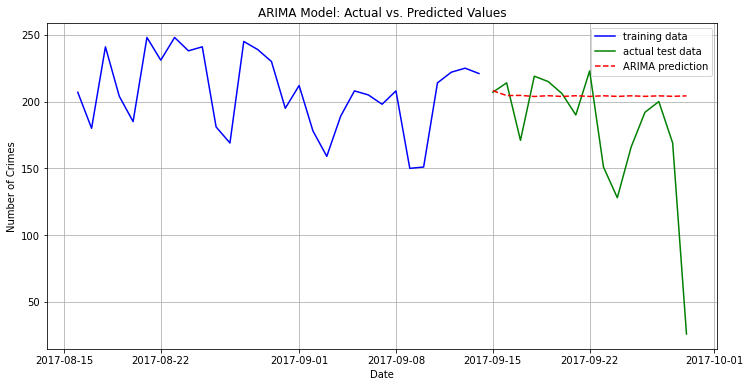

3024.8545410689017

In [10]:
# ARIMA 모델 학습 (ARIMA는 ARMA의 확장 모델)
# 여기서는 (p=2, d=1, q=2) 초기 파라미터로 ARIMA 모델 설정
arima_model = ARIMA(train_data, order=(2, 1, 2))
arima_result = arima_model.fit()

# 향후 15일의 데이터를 예측
arima_forecast = arima_result.forecast(steps=15)

# 성능 비교를 위한 평균 제곱 오차(MSE) 계산
mse = mean_squared_error(test_data, arima_forecast)

# 실제 값과 예측 값을 비교하는 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(train_data[-30:], label="training data", color="blue")  # 학습 데이터 중 최근 30일
plt.plot(test_data, label="actual test data", color="green")  # 테스트 데이터 (실제 값)
plt.plot(test_data.index, arima_forecast, label="ARIMA prediction", color="red", linestyle="--")  # ARIMA 예측 결과
plt.title("ARIMA Model: Actual vs. Predicted Values")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")
plt.legend()
plt.grid(True)
plt.show()

# 성능 지표 출력 (MSE 값)
mse